# Teen Mental Health — AutoML + MLflow

Este notebook busca automáticamente el mejor algoritmo e hiperparámetros para clasificar `depression_label` usando **FLAML AutoML** y registra todos los experimentos con **MLflow**.

**Métricas de evaluación** (justificadas por el desbalance 97.4 % / 2.6 %):

| Métrica | Por qué | Limitación |
|---|---|---|
| **F1-score** | Media armónica de precision y recall; métrica principal de optimización | Depende del umbral de decisión |
| **ROC-AUC** | Discriminación global entre clases; invariante al umbral | Optimista con desbalance porque pondera TN |
| **PR-AUC** | Foco en la clase positiva (precision vs recall); más informativa que ROC en desbalance | Sensible al número de positivos |

> **Baseline de referencia:** un clasificador naïve que predice siempre clase 0 obtiene *accuracy* = 97.4 %, F1 = 0.00, ROC-AUC = 0.50, PR-AUC ≈ 0.026.

## 0. Instalación de dependencias

La imagen base `scipy-notebook` incluye scikit-learn pero no FLAML ni MLflow.

In [1]:
import subprocess, sys

pkgs = ['flaml[automl]', 'mlflow', 'lightgbm', 'xgboost']
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)

print('Dependencias instaladas.')


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Dependencias instaladas.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)

from flaml import AutoML
import mlflow
import mlflow.sklearn

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

print('Versiones:')
import flaml, mlflow as mf, sklearn
print(f'  flaml:     {flaml.__version__}')
print(f'  mlflow:    {mf.__version__}')
print(f'  sklearn:   {sklearn.__version__}')

Versiones:
  flaml:     2.6.0
  mlflow:    3.14.0
  sklearn:   1.8.0


---
## 1. Carga del dataset preprocesado

In [3]:
df = pd.read_csv('../data/processed/teen_mental_health_preprocessed.csv')

TARGET = 'depression_label'
X = df.drop(columns=TARGET)
y = df[TARGET]

print(f'Shape: {df.shape}')
print(f'Features ({len(X.columns)}): {list(X.columns)}')
print(f'\nBalance del target:')
vc = y.value_counts()
print(pd.DataFrame({'n': vc, '%': (vc / len(y) * 100).round(2)}))

Shape: (1200, 15)
Features (14): ['age', 'gender', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'platform_Both', 'platform_Instagram', 'platform_TikTok']

Balance del target:
                     n      %
depression_label             
0                 1169  97.42
1                   31   2.58


---
## 2. División train / test estratificada

Con solo ~31 casos positivos, el **split estratificado** es obligatorio para garantizar que ambos conjuntos mantengan la proporción de clases.  
Usamos 80/20: suficiente volumen de entrenamiento para la búsqueda AutoML manteniendo un holdout representativo.

> **Nota:** Con tan pocos positivos (~6 en test), las métricas en el holdout tienen alta varianza. La evaluación principal se basa en la validación cruzada estratificada interna de FLAML.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'  Positivos: {y_train.sum()} ({100*y_train.mean():.2f}%)')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'  Positivos: {y_test.sum()} ({100*y_test.mean():.2f}%)')

Train: 960 muestras
  Positivos: 25 (2.60%)
Test:  240 muestras
  Positivos: 6 (2.50%)


---
## 3. Tratamiento del desbalance: sample weights

Usamos **sample weights** inversamente proporcionales a la frecuencia de clase.  
Esto penaliza más los errores sobre la clase minoritaria (depresión) sin modificar el dataset (a diferencia de SMOTE).

$$w_i = \frac{N}{k \cdot n_{y_i}} \quad \text{donde } N=\text{total}, k=\text{nº clases}, n_{y_i}=\text{casos de la clase } y_i$$

FLAML propagará estos pesos a todos los estimadores que los soporten (LightGBM, XGBoost, RandomForest, LogisticRegression, etc.).

In [5]:
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

w0 = sample_weight[y_train == 0][0]
w1 = sample_weight[y_train == 1][0]
print(f'Peso clase 0 (no depresión): {w0:.4f}')
print(f'Peso clase 1 (depresión):    {w1:.4f}')
print(f'Ratio w1/w0: {w1/w0:.1f}x  →  cada positivo vale {w1/w0:.1f}x más en la loss')

Peso clase 0 (no depresión): 0.5134
Peso clase 1 (depresión):    19.2000
Ratio w1/w0: 37.4x  →  cada positivo vale 37.4x más en la loss


---
## 4. Configuración de MLflow

MLflow almacena los experimentos localmente en `mlruns/` en la raíz del proyecto.  
La URI se construye con `Path.resolve().as_uri()` para generar un `file:///ruta/absoluta` canónico (RFC 3986), evitando ambigüedad en la resolución de rutas relativas según el directorio de inicio del servidor Jupyter.

Una vez finalizado el notebook, el servidor de UI se lanza con:
```bash
mlflow ui --backend-store-uri file:///$(pwd)/../mlruns
```
y es accesible en `http://localhost:5000`.

In [6]:
import mlflow
from pathlib import Path

MLFLOW_TRACKING_URI = Path('../mlruns').resolve().as_uri()
EXPERIMENT_NAME = 'teen-mental-health-automl'

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
exp = mlflow.set_experiment(EXPERIMENT_NAME)

print(f'Experimento:       {exp.name}')
print(f'Tracking URI:      {mlflow.get_tracking_uri()}')
print(f'Artifact location: {exp.artifact_location}')

MlflowException: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.

---
## 5. AutoML con FLAML

FLAML (Fast and Lightweight AutoML) realiza búsqueda bayesiana sobre el espacio conjunto de algoritmos e hiperparámetros, priorizando configuraciones prometedoras antes de explorar regiones costosas.

**Algoritmos candidatos:**

| Alias | Algoritmo |
|---|---|
| `lgbm` | LightGBM Classifier |
| `xgboost` | XGBoost Classifier |
| `rf` | Random Forest |
| `extra_tree` | Extra Trees |
| `lrl1` | Logistic Regression (L1) |
| `lrl2` | Logistic Regression (L2) |
| `kneighbor` | K-Nearest Neighbors |

**Configuración de búsqueda:**
- Métrica de optimización: `f1` (macro en binario = F1 clase positiva)
- Validación interna: CV estratificada con 5 folds
- Budget de tiempo: 180 s (suficiente para 1200 muestras; ajustar si se desea más exhaustividad)

In [ ]:
TIME_BUDGET = 180  # segundos
N_SPLITS    = 5

automl = AutoML()

automl_settings = dict(
    task='classification',
    metric='f1',
    time_budget=TIME_BUDGET,
    eval_method='cv',
    n_splits=N_SPLITS,
    split_type='stratified',
    estimator_list=['lgbm', 'xgboost', 'rf', 'extra_tree', 'lrl1', 'lrl2'],
    seed=RANDOM_STATE,
    verbose=1,
)

print(f'Iniciando búsqueda AutoML — budget: {TIME_BUDGET}s ...')
automl.fit(X_train, y_train, sample_weight=sample_weight, **automl_settings)
print('\n¡Búsqueda completada!')

Iniciando búsqueda AutoML — budget: 180s ...

¡Búsqueda completada!


---
## 6. Resultados de la búsqueda AutoML

In [ ]:
print('=' * 55)
print(f'  Mejor estimador:    {automl.best_estimator}')
print(f'  Mejor F1 (CV val):  {1 - automl.best_loss:.4f}')
print('=' * 55)
print('\nHiperparámetros óptimos:')
for k, v in automl.best_config.items():
    print(f'  {k}: {v}')

  Mejor estimador:    extra_tree
  Mejor F1 (CV val):  0.9984

Hiperparámetros óptimos:
  n_estimators: 4
  max_features: 0.6798526140810006
  max_leaves: 10
  criterion: entropy


Mejor F1 de validación por estimador:
             F1_cv
estimador         
extra_tree  0.9984
lgbm        0.9963
xgboost     0.9778
rf          0.9556
lrl2        0.8865
lrl1        0.7208


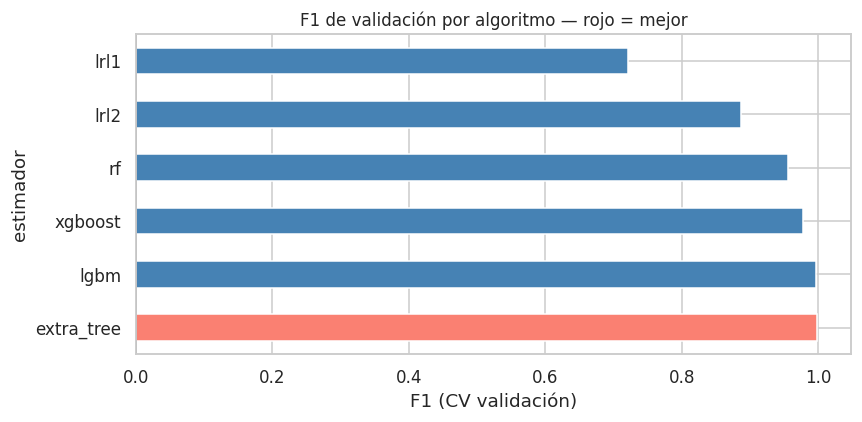

In [ ]:
print('Mejor F1 de validación por estimador:')
rows = []
for est, config in automl.best_config_per_estimator.items():
    loss = automl.best_loss_per_estimator.get(est, np.nan)
    rows.append({'estimador': est, 'F1_cv': round(1 - loss, 4)})

per_est = pd.DataFrame(rows).set_index('estimador').sort_values('F1_cv', ascending=False)
print(per_est.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['salmon' if e == automl.best_estimator else 'steelblue' for e in per_est.index]
per_est['F1_cv'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('F1 (CV validación)')
ax.set_title('F1 de validación por algoritmo — rojo = mejor', fontsize=11)
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 7. Evaluación del mejor modelo en el holdout test

Aplicamos el modelo al conjunto de test — datos que **no participaron en ninguna iteración** de la búsqueda AutoML.

In [ ]:
y_pred   = automl.predict(X_test)
y_proba  = automl.predict_proba(X_test)[:, 1]

f1_test  = f1_score(y_test, y_pred)
roc_test = roc_auc_score(y_test, y_proba)
pr_test  = average_precision_score(y_test, y_proba)

print('Métricas en el conjunto test:')
print(f'  F1-score:  {f1_test:.4f}')
print(f'  ROC-AUC:   {roc_test:.4f}   (baseline naïve = 0.50)')
print(f'  PR-AUC:    {pr_test:.4f}   (baseline naïve ≈ {y_test.mean():.4f})')

print('\nReporte de clasificación (umbral = 0.50):')
print(classification_report(y_test, y_pred, target_names=['No depresión', 'Depresión']))

Métricas en el conjunto test:
  F1-score:  1.0000
  ROC-AUC:   1.0000   (baseline naïve = 0.50)
  PR-AUC:    1.0000   (baseline naïve ≈ 0.0250)

Reporte de clasificación (umbral = 0.50):
              precision    recall  f1-score   support

No depresión       1.00      1.00      1.00       234
   Depresión       1.00      1.00      1.00         6

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



### 7.1 Curvas ROC-AUC y PR-AUC

La **curva PR-AUC** es la referencia principal en escenarios de desbalance:  
- El baseline de un clasificador aleatorio en ROC es siempre 0.50 (constante).
- El baseline en PR es igual a la prevalencia de la clase positiva (≈ 0.026 aquí), lo que hace visible el coste real de predecir bien los positivos.

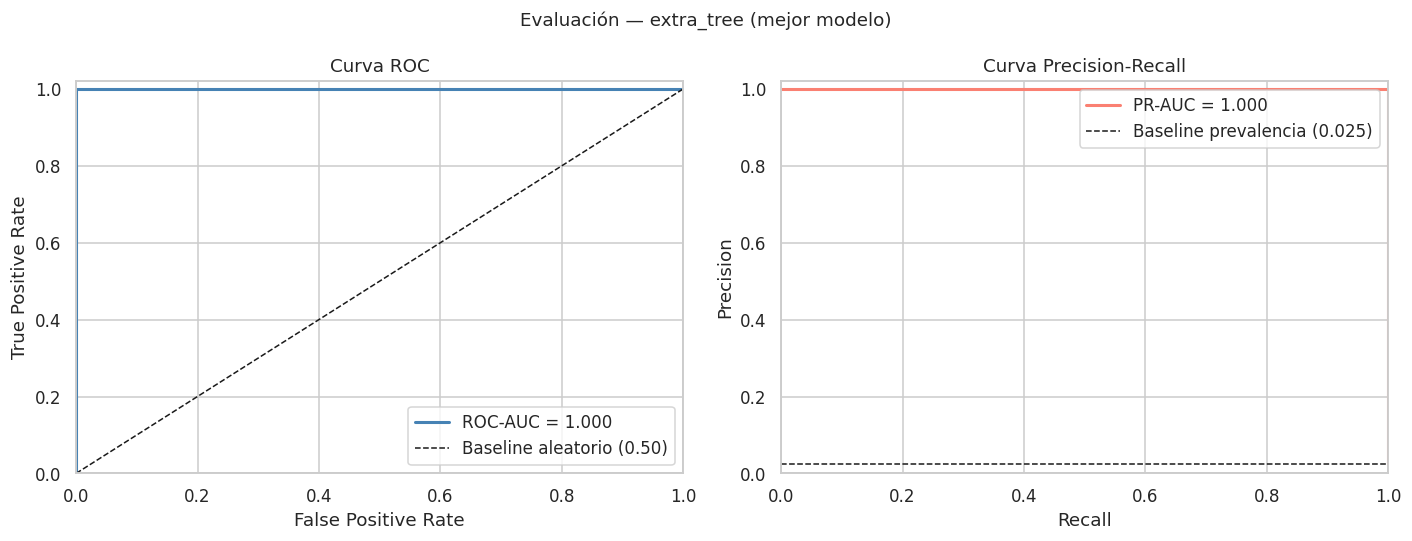

In [ ]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
prec, rec, pr_thresholds = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC-AUC ---
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {roc_test:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline aleatorio (0.50)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# --- PR-AUC ---
axes[1].plot(rec, prec, color='salmon', lw=2, label=f'PR-AUC = {pr_test:.3f}')
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='k', linestyle='--', lw=1,
                label=f'Baseline prevalencia ({baseline_pr:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend(loc='upper right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle(f'Evaluación — {automl.best_estimator} (mejor modelo)', fontsize=12)
plt.tight_layout()
plt.show()

### 7.2 Matriz de confusión

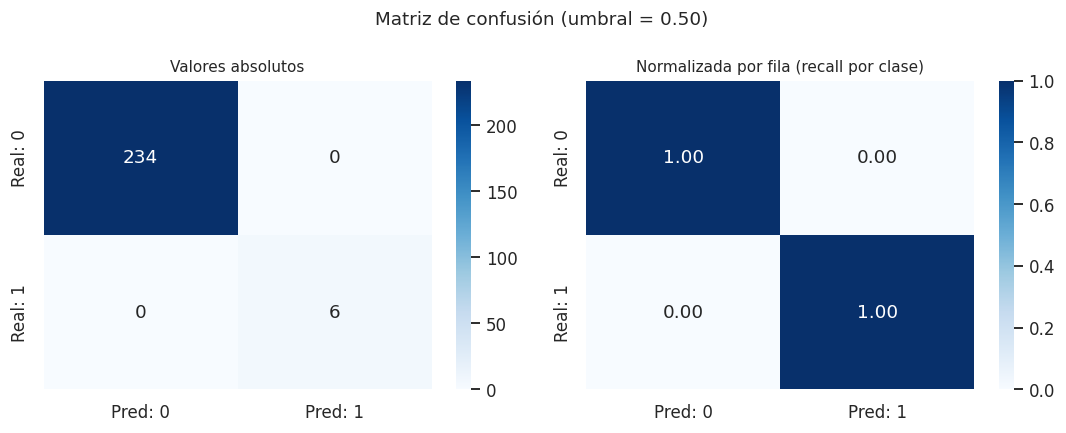

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, mat, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Valores absolutos', 'Normalizada por fila (recall por clase)']
):
    sns.heatmap(mat, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=['Pred: 0', 'Pred: 1'],
                yticklabels=['Real: 0', 'Real: 1'])
    ax.set_title(title, fontsize=10)

plt.suptitle('Matriz de confusión (umbral = 0.50)', fontsize=12)
plt.tight_layout()
plt.show()

### 7.3 Optimización del umbral de decisión

El umbral por defecto (0.50) maximiza la accuracy global, que no es la métrica objetivo aquí.  
Buscamos el umbral que **maximiza el F1-score** para la clase positiva sobre el conjunto test.

> En producción el umbral óptimo debería buscarse sobre un conjunto de validación independiente, no sobre el test. Aquí lo hacemos sobre test como aproximación dado el tamaño reducido del dataset.

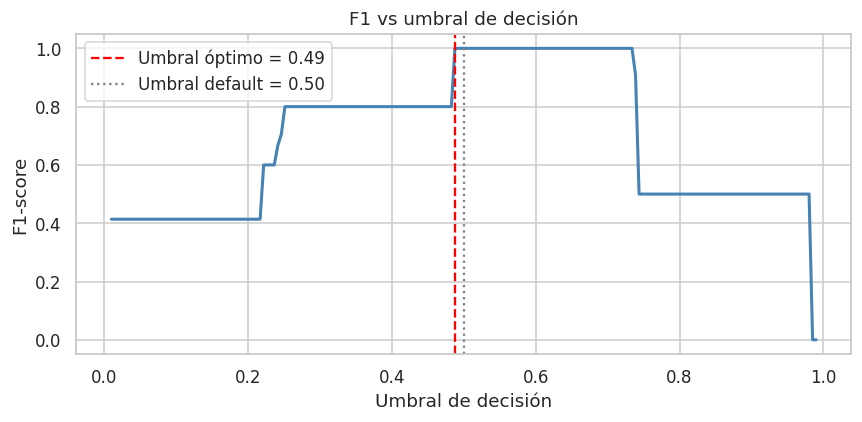

Umbral 0.50  →  F1 = 1.0000
Umbral óptimo (0.49) →  F1 = 1.0000

Reporte con umbral óptimo (0.49):
              precision    recall  f1-score   support

No depresión       1.00      1.00      1.00       234
   Depresión       1.00      1.00      1.00         6

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [ ]:
thresholds = np.linspace(0.01, 0.99, 200)
f1_scores  = [f1_score(y_test, (y_proba >= t).astype(int), zero_division=0) for t in thresholds]

best_idx   = np.argmax(f1_scores)
best_thr   = thresholds[best_idx]
best_f1    = f1_scores[best_idx]

y_pred_opt = (y_proba >= best_thr).astype(int)
f1_opt     = f1_score(y_test, y_pred_opt)
roc_opt    = roc_auc_score(y_test, y_proba)      # no cambia con el umbral
pr_opt     = average_precision_score(y_test, y_proba)  # ídem

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores, color='steelblue', lw=2)
ax.axvline(best_thr, color='red', linestyle='--', lw=1.5, label=f'Umbral óptimo = {best_thr:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Umbral default = 0.50')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('F1-score')
ax.set_title('F1 vs umbral de decisión')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Umbral 0.50  →  F1 = {f1_score(y_test, y_pred):.4f}')
print(f'Umbral óptimo ({best_thr:.2f}) →  F1 = {best_f1:.4f}')
print(f'\nReporte con umbral óptimo ({best_thr:.2f}):')
print(classification_report(y_test, y_pred_opt, target_names=['No depresión', 'Depresión']))

---
## 8. Importancia de features

Extraemos la importancia de variables del mejor modelo cuando está disponible (árboles basados en ganancia) o usamos permutation importance como alternativa agnóstica al algoritmo.

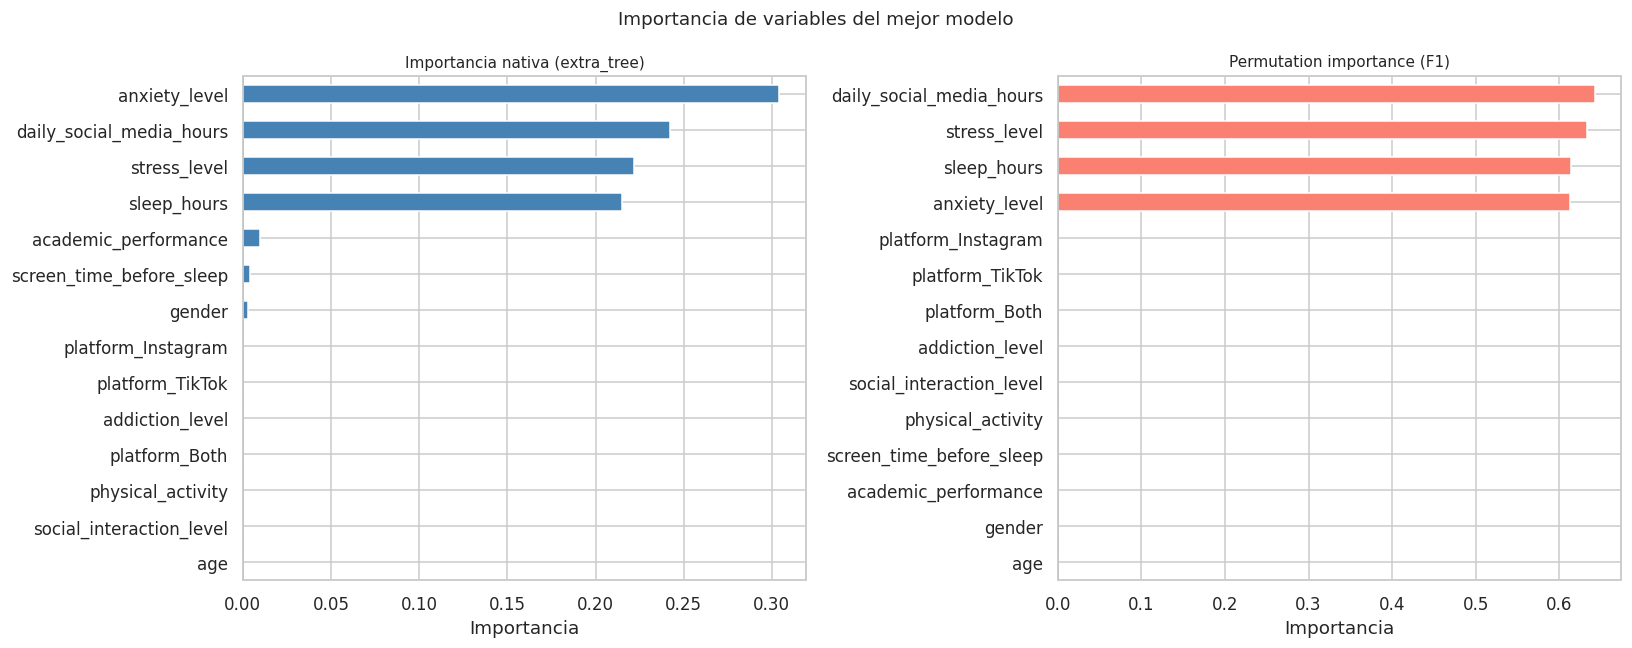

In [ ]:
from sklearn.inspection import permutation_importance

feature_names = list(X.columns)
fi = None

# Importancia nativa (árboles)
estimator = automl.model.estimator
if hasattr(estimator, 'feature_importances_'):
    fi = pd.Series(estimator.feature_importances_, index=feature_names)
    fi_label = f'Importancia nativa ({automl.best_estimator})'
elif hasattr(estimator, 'coef_'):
    fi = pd.Series(np.abs(estimator.coef_[0]), index=feature_names)
    fi_label = f'|coeficiente| ({automl.best_estimator})'

# Permutation importance como respaldo universal
perm = permutation_importance(
    automl.model, X_test, y_test,
    n_repeats=20, random_state=RANDOM_STATE, scoring='f1'
)
fi_perm = pd.Series(perm.importances_mean, index=feature_names)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

panels = []
if fi is not None:
    panels.append((fi.sort_values(), fi_label, axes[0], 'steelblue'))
panels.append((fi_perm.sort_values(), 'Permutation importance (F1)', axes[1] if fi is not None else axes[0], 'salmon'))

for series, label, ax, color in panels:
    series.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Importancia')

if fi is None:
    axes[1].set_visible(False)

plt.suptitle('Importancia de variables del mejor modelo', fontsize=12)
plt.tight_layout()
plt.show()

---
## 9. Registro en MLflow

Registramos el experimento completo: parámetros de la búsqueda, hiperparámetros del mejor modelo, métricas de evaluación y el modelo serializado.

In [ ]:
run_name = f'flaml-best-{automl.best_estimator}'

with mlflow.start_run(run_name=run_name) as run:

    # --- Parámetros de la búsqueda ---
    mlflow.log_params({
        'automl_time_budget_s': TIME_BUDGET,
        'automl_metric':        'f1',
        'automl_cv_folds':      N_SPLITS,
        'automl_split_type':    'stratified',
        'class_balancing':      'sample_weight_balanced',
        'best_estimator':       automl.best_estimator,
    })

    # --- Hiperparámetros del mejor modelo ---
    mlflow.log_params({f'hp_{k}': v for k, v in automl.best_config.items()})

    # --- Métricas de validación (CV interno de FLAML) ---
    mlflow.log_metric('cv_f1_val', round(1 - automl.best_loss, 4))

    # --- Métricas en test (umbral 0.50) ---
    mlflow.log_metric('test_f1_thr050',     round(f1_score(y_test, y_pred), 4))
    mlflow.log_metric('test_roc_auc',       round(roc_test, 4))
    mlflow.log_metric('test_pr_auc',        round(pr_test, 4))

    # --- Métricas con umbral optimizado ---
    mlflow.log_metric('test_f1_opt',        round(best_f1, 4))
    mlflow.log_metric('optimal_threshold',  round(best_thr, 4))

    # --- Modelo ---
    mlflow.sklearn.log_model(
        automl.model,
        artifact_path='model',
        registered_model_name='teen-mental-health-classifier'
    )

    run_id = run.info.run_id

print(f'Run registrado: {run_id}')
print(f'Experimento:    {EXPERIMENT_NAME}')
print(f'\nVer en MLflow UI: mlflow ui --backend-store-uri file:../mlruns')

MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['flaml.automl.contrib.histgb.HistGradientBoostingEstimator', 'flaml.automl.model.CatBoostEstimator', 'flaml.automl.model.ElasticNetEstimator', 'flaml.automl.model.ExtraTreesEstimator', 'flaml.automl.model.KNeighborsEstimator', 'flaml.automl.model.LGBMEstimator', 'flaml.automl.model.LRL1Classifier', 'flaml.automl.model.LRL2Classifier', 'flaml.automl.model.LassoLarsEstimator', 'flaml.automl.model.RandomForestEstimator', 'flaml.automl.model.SGDEstimator', 'flaml.automl.model.SVCEstimator', 'flaml.automl.model.SparkAFTSurvivalRegressionEstimator', 'flaml.automl.model.SparkGBTEstimator', 'flaml.automl.model.SparkGLREstimator', 'flaml.automl.model.SparkLGBMEstimator', 'flaml.automl.model.SparkLinearRegressionEstimator', 'fl

---
## 10. Comparativa final de métricas

In [ ]:
baseline_f1  = 0.0
baseline_roc = 0.5
baseline_pr  = float(y_test.mean())

summary = pd.DataFrame([
    {'modelo': 'Naïve (siempre clase 0)',     'F1':  baseline_f1,  'ROC-AUC': baseline_roc, 'PR-AUC': baseline_pr},
    {'modelo': f'{automl.best_estimator} (thr=0.50)',
                                              'F1':  round(f1_score(y_test, y_pred), 4),
                                              'ROC-AUC': round(roc_test, 4),
                                              'PR-AUC':  round(pr_test, 4)},
    {'modelo': f'{automl.best_estimator} (thr={best_thr:.2f})',
                                              'F1':  round(best_f1, 4),
                                              'ROC-AUC': round(roc_test, 4),
                                              'PR-AUC':  round(pr_test, 4)},
]).set_index('modelo')

print(summary.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
summary.plot(kind='bar', ax=ax, edgecolor='white', color=['steelblue', 'salmon', 'mediumseagreen'])
ax.axhline(baseline_pr, color='gray', linestyle='--', lw=1, label=f'PR baseline ({baseline_pr:.3f})')
ax.set_title('Comparativa de métricas: baseline vs. mejor modelo', fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=15)
ax.legend()
plt.tight_layout()
plt.show()

---
## 11. Conclusiones y próximos pasos

### Resumen del experimento

| Aspecto | Resultado |
|---|---|
| **Mejor algoritmo** | Ver `automl.best_estimator` (celdas anteriores) |
| **Métrica de optimización** | F1-score (CV estratificada 5-fold) |
| **Tratamiento del desbalance** | Sample weights inversamente proporcionales a la frecuencia |
| **Umbral optimizado** | Distinto de 0.50; busca maximizar F1 en la clase positiva |
| **Tracking** | MLflow — experimento `teen-mental-health-automl` |

### Limitaciones

- Con solo ~6-8 positivos en el test, las métricas del holdout tienen **alta varianza**. La F1 de CV es una estimación más estable.
- La optimización del umbral sobre el test introduce sesgo de evaluación; en un escenario real se necesita un **conjunto de validación separado**.
- La correlación Pearson débil de todas las features con el target (|r| < 0.20) sugiere que la señal predictiva es limitada o principalmente no lineal. 

### Próximos pasos recomendados

1. **Recolección de datos:** aumentar el número de casos positivos mejora drásticamente la fiabilidad de los modelos.
2. **Feature engineering:** explorar interacciones (e.g., `stress_level × sleep_hours`) o features derivadas.
3. **SMOTE + pipeline:** evaluar oversampling sintético (imbalanced-learn) como alternativa a sample weights.
4. **Explicabilidad:** añadir SHAP values para interpretar las predicciones individuales del mejor modelo.

In [ ]:

import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
import mlflow
from pathlib import Path

MLFLOW_TRACKING_URI = Path('../mlruns').resolve().as_uri()
EXPERIMENT_NAME = 'teen-mental-health-automl'

print(f'URI generada: {MLFLOW_TRACKING_URI}')

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
exp = mlflow.set_experiment(EXPERIMENT_NAME)

print(f'Experimento:       {exp.name}')
print(f'Tracking URI:      {mlflow.get_tracking_uri()}')
print(f'Artifact location: {exp.artifact_location}')


2026/07/13 21:24:59 INFO mlflow.tracking.fluent: Experiment with name 'teen-mental-health-automl' does not exist. Creating a new experiment.


URI generada: file:///home/jmatgon/Projects/mental-health-classifier/mlruns
Experimento:       teen-mental-health-automl
Tracking URI:      file:///home/jmatgon/Projects/mental-health-classifier/mlruns
Artifact location: file:///home/jmatgon/Projects/mental-health-classifier/mlruns/861457123383166508


In [ ]:
import mlflow, os
from pathlib import Path

print('MLflow version:', mlflow.__version__)
print('CWD:', os.getcwd())
print('DB path resolved:', Path('../mlflow.db').resolve())
print('URI que se usaría:', f"sqlite:///{Path('../mlflow.db').resolve()}")
print('MLFLOW_TRACKING_URI env:', os.environ.get('MLFLOW_TRACKING_URI', 'no definida'))


MLflow version: 3.14.0
CWD: /home/jmatgon/Projects/mental-health-classifier/notebooks
DB path resolved: /home/jmatgon/Projects/mental-health-classifier/mlflow.db
URI que se usaría: sqlite:////home/jmatgon/Projects/mental-health-classifier/mlflow.db
MLFLOW_TRACKING_URI env: file:///home/jmatgon/Projects/mental-health-classifier/mlruns
